In [1]:
!pip -q install onnx onnxruntime onnxsim onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 85.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 10.0 MB/s eta 0:00:00


In [2]:
import os, json, random, shutil, zipfile
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models
import torchvision.transforms as transforms
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from torchvision.datasets import ImageFolder

FRAMES_ROOT = Path("/kaggle/input/datasets/nikita041/bukva-frames-dataset-8fps-for-mobilenetv2-hand-cor")
CKPT_DIR    = Path("/kaggle/working")

IMG_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 20
LR = 3e-4

DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"

CLASSES = {
    0: "no_event", 1: "Ё", 2: "А", 3: "Б", 4: "В", 5: "Г", 6: "Д", 7: "Е",
    8: "Ж", 9: "З", 10: "И", 11: "Й", 12: "К", 13: "Л", 14: "М", 15: "Н",
    16: "О", 17: "П", 18: "Р", 19: "С", 20: "Т", 21: "У", 22: "Ф", 23: "Х",
    24: "Ц", 25: "Ч", 26: "Ш", 27: "Щ", 28: "Ъ", 29: "Ы", 30: "Ь", 31: "Э",
    32: "Ю", 33: "Я",
}

In [3]:
# Важно: RandomHorizontalFlip УДАЛЕН. Дактиль асимметричен (правая/левая рука важна)
train_tf = transforms.Compose([
    # Картинки у нас уже 224x224, но Resize нужен для подстраховки
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    # Легкий поворот (до 15 градусов) и сдвиг (на 5%), чтобы имитировать дрожание камеры
    transforms.RandomAffine(degrees=15, translate=(0.05, 0.05)),
    # Меняем яркость и контраст, чтобы модель работала при разном освещении
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    # Превращаем в тензор и нормализуем под стандарт MobileNet
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_ds = datasets.ImageFolder(FRAMES_ROOT / "train", transform=train_tf)
val_ds   = datasets.ImageFolder(FRAMES_ROOT / "val",   transform=val_tf)
NUM_CLASSES = len(train_ds.classes)

# Сохраняем маппинг классов (чтобы на NPU понимать, какой индекс какую букву значит)
IDX_TO_LETTER = {idx: CLASSES[int(name)] for name, idx in train_ds.class_to_idx.items()}
with open(CKPT_DIR / "idx_to_letter.json", "w", encoding="utf-8") as f:
    json.dump(IDX_TO_LETTER, f, ensure_ascii=False, indent=2)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 127MB/s]
/tmp/ipykernel_23/3624993645.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=USE_AMP)
Эпоха 1/20:   0%|          | 0/398 [00:00<?, ?it/s]/tmp/ipykernel_23/3624993645.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_23/3624993645.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


[Эпоха 1] Train Loss: 1.802 | Val Loss: 1.658 | Val Acc: 0.6491 | F1: 0.6449


Эпоха 2/20:   0%|          | 0/398 [00:00<?, ?it/s]/tmp/ipykernel_23/3624993645.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_23/3624993645.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


[Эпоха 2] Train Loss: 1.171 | Val Loss: 1.666 | Val Acc: 0.6675 | F1: 0.6709


...

[Эпоха 18] Train Loss: 0.681 | Val Loss: 1.657 | Val Acc: 0.6941 | F1: 0.6965


Эпоха 19/20:   0%|          | 0/398 [00:00<?, ?it/s]/tmp/ipykernel_23/3624993645.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_23/3624993645.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


[Эпоха 19] Train Loss: 0.680 | Val Loss: 1.657 | Val Acc: 0.6958 | F1: 0.6979


Эпоха 20/20:   0%|          | 0/398 [00:00<?, ?it/s]/tmp/ipykernel_23/3624993645.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_23/3624993645.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


[Эпоха 20] Train Loss: 0.680 | Val Loss: 1.659 | Val Acc: 0.6950 | F1: 0.6978
Лучшая точность: 0.6958


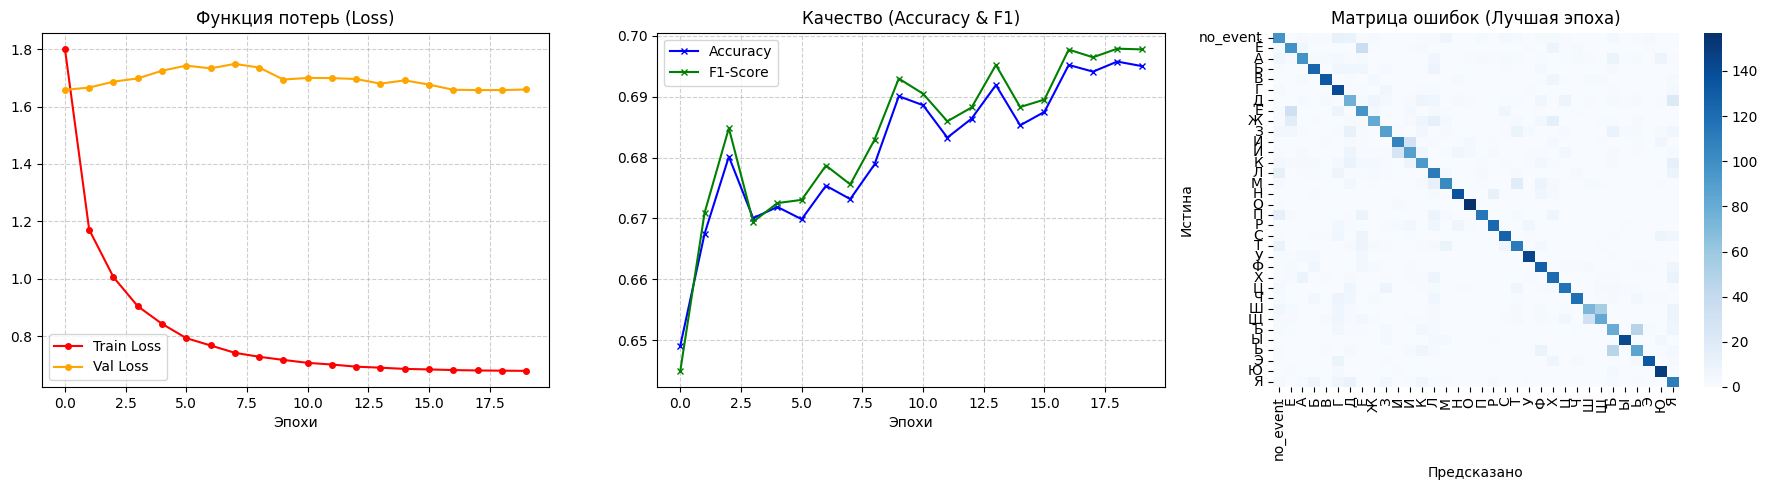

In [4]:
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, NUM_CLASSES)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler    = torch.cuda.amp.GradScaler(enabled=USE_AMP)

CKPT_PATH = CKPT_DIR / "bukva_mobilenet_v2_8fps_hands_correct.pt"

history = {
    'train_loss': [], 'val_loss': [], 
    'val_acc': [], 'val_f1': [], 'val_precision': [], 'val_recall': []
}
best_preds, best_labels = [], []
best_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    for imgs, labels in tqdm(train_loader, desc=f"Эпоха {epoch}/{EPOCHS}", leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            out = model(imgs)
            loss = criterion(out, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()
    
    scheduler.step()
    epoch_loss = running_loss / len(train_loader)
    history['train_loss'].append(epoch_loss)
    
    model.eval()
    val_running_loss = 0.0
    correct = total = 0
    current_preds, current_labels = [], []
    
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                out = model(imgs)
                loss = criterion(out, labels)
            
            val_running_loss += loss.item()
            preds = out.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.numel()
            
            current_preds.extend(preds.cpu().numpy())
            current_labels.extend(labels.cpu().numpy())
            
    # Расчет новых метрик
    val_loss = val_running_loss / len(val_loader)
    val_acc = correct / total
    
    # Расчет Precision, Recall, F1
    precision, recall, f1, _ = precision_recall_fscore_support(
        current_labels, current_preds, average='macro', zero_division=0
    )
    
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_precision'].append(precision)
    history['val_recall'].append(recall)
    history['val_f1'].append(f1)
    
    print(f"[Эпоха {epoch}] Train Loss: {epoch_loss:.3f} | Val Loss: {val_loss:.3f} | Val Acc: {val_acc:.4f} | F1: {f1:.4f}")
    
    if val_acc > best_acc:
        best_acc = val_acc
        best_preds, best_labels = current_preds, current_labels
        torch.save({"model": model.state_dict()}, CKPT_PATH)

print(f"Лучшая точность: {best_acc:.4f}")

# Сохраняем историю обучения в JSON
with open(CKPT_DIR / "training_history.json", "w", encoding="utf-8") as f:
    json.dump(history, f, indent=4)

# Генерируем и сохраняем полный отчет по всем классам
class_names = [CLASSES[i] for i in range(NUM_CLASSES)]
report = classification_report(best_labels, best_preds, target_names=class_names, output_dict=True, zero_division=0)
with open(CKPT_DIR / "classification_report.json", "w", encoding="utf-8") as f:
    json.dump(report, f, indent=4, ensure_ascii=False)

plt.figure(figsize=(18, 5))

# График 1: Функция потерь (Loss)
plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], label='Train Loss', color='red', marker='o', markersize=4)
plt.plot(history['val_loss'], label='Val Loss', color='orange', marker='o', markersize=4)
plt.title('Функция потерь (Loss)')
plt.xlabel('Эпохи')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# График 2: Метрики классификации
plt.subplot(1, 3, 2)
plt.plot(history['val_acc'], label='Accuracy', color='blue', marker='x', markersize=4)
plt.plot(history['val_f1'], label='F1-Score', color='green', marker='x', markersize=4)
plt.title('Качество (Accuracy & F1)')
plt.xlabel('Эпохи')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# График 3: Матрица ошибок
plt.subplot(1, 3, 3)
cm = confusion_matrix(best_labels, best_preds)
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Матрица ошибок (Лучшая эпоха)')
plt.xlabel('Предсказано')
plt.ylabel('Истина')

plt.tight_layout()
plt.savefig(CKPT_DIR / "training_metrics.png", dpi=150)
plt.show()

In [5]:
calib_imgs = []
train_dir = FRAMES_ROOT / "train"
for d in os.listdir(train_dir):
    imgs = list((train_dir / d).glob("*.jpg"))
    calib_imgs.extend([str(p) for p in imgs[:10]]) 
random.shuffle(calib_imgs)
calib_imgs = calib_imgs[:200]

with open(CKPT_DIR / "dataset_8fps_hands_correct.txt", "w") as f:
    f.write("\n".join(calib_imgs))

print("Калибровка создана.")

Калибровка создана.


In [6]:
zip_name = "/kaggle/working/bukva_mobilenet_results.zip"

files_to_zip = [
    "bukva_mobilenet_v2_8fps_hands_correct.pt",
    "idx_to_letter.json",
    "dataset_8fps_hands_correct.txt",
    "training_metrics.png",
    "training_history.json",       # Сырые данные по эпохам
    "classification_report.json"   # Детальный отчет (Precision/Recall/F1) по каждой букве
]

print("Архивация...")

with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for file in files_to_zip:
        file_path = f"/kaggle/working/{file}"
        if os.path.exists(file_path):
            zipf.write(file_path, arcname=file)
            print(f"Добавлен в архив: {file}")
        else:
            print(f"Внимание: файл {file} не найден и пропущен.")

print(f"\n Готово! Архив успешно создан: {zip_name}")

Архивация...
Добавлен в архив: bukva_mobilenet_v2_8fps_hands_correct.pt
Добавлен в архив: idx_to_letter.json
Добавлен в архив: dataset_8fps_hands_correct.txt
Добавлен в архив: training_metrics.png
Добавлен в архив: training_history.json
Добавлен в архив: classification_report.json

 Готово! Архив успешно создан: /kaggle/working/bukva_mobilenet_results.zip
